# Insurance Risk Analytics - Exploratory Data Analysis

## Objective

The objective of this analysis is to explore historical insurance data to identify patterns in risk, profitability, and customer behavior. The findings will support risk-based pricing and strategic decision-making for AlphaCare Insurance Solutions (ACIS).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [25]:
from src.data_loader import load_data
from src.eda import calculate_loss_ratio
from src.eda import calculate_margin

In [2]:
import pandas as pd 
df = pd.read_csv(
    "../data/ML.txt",   # your file name
    sep='|'
)
df.head()

C:\Users\dania\AppData\Local\Temp\ipykernel_17072\204511049.py:2: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


## Dataset Overview

The dataset contains historical auto insurance policy and claims data from February 2014 to August 2015.

It includes:
- Client information
- Vehicle characteristics
- Policy details
- Claims and premium information
- Geographic information

In [4]:
df.shape

(1000098, 52)

In [26]:
missing = df.isnull().sum().sort_values(ascending=False)

missing.head(20)

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
NumberOfDoors                  552
VehicleType                    552
kilowatts                      552
cubiccapacity                  552
Cylinders                      552
Model                          552
make                           552
VehicleIntroDate               552
bodytype                       552
dtype: int64

# Data Quality Assessment

## Missing Value Analysis

The dataset contains several columns with substantial missing values. Understanding the extent and nature of these missing values is important for ensuring reliable analysis and modeling.

### Columns with the Highest Missing Values

| Column | Missing Values |
|---|---|
| NumberOfVehiclesInFleet | 1,000,098 |
| CrossBorder | 999,400 |
| CustomValueEstimate | 779,642 |
| Rebuilt | 641,901 |
| Converted | 641,901 |
| WrittenOff | 641,901 |
| NewVehicle | 153,295 |
| Bank | 145,961 |
| AccountType | 40,232 |
| Gender | 9,536 |
| MaritalStatus | 8,259 |

### Observations

- `NumberOfVehiclesInFleet` is completely empty and provides no usable information for analysis. This column will likely be removed.
- `CrossBorder` contains almost entirely missing values, making it unreliable for meaningful analysis.
- `CustomValueEstimate` has a very high proportion of missing values, which may limit its usefulness unless carefully imputed.
- `WrittenOff`, `Rebuilt`, and `Converted` contain large amounts of missing data, potentially because these events occur infrequently.
- Customer-related variables such as `Gender`, `MaritalStatus`, and `AccountType` contain relatively low missingness and can likely be retained with minimal preprocessing.
- Vehicle-related variables (`VehicleType`, `Model`, `make`, `Cylinders`, `kilowatts`, etc.) contain very few missing values relative to the dataset size and remain valuable for risk analysis.

---

# Dataset Structure and Data Types

The dataset contains:

- **1,000,098 rows**
- **52 columns**


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

### Data Type Distribution

| Data Type | Count |
|---|---|
| String/Object Columns | 36 |
| Float Columns | 11 |
| Integer Columns | 4 |
| Boolean Columns | 1 |

In [28]:
numeric_cols = [
    'TotalPremium',
    'TotalClaims',
    'CustomValueEstimate',
    'CalculatedPremiumPerTerm',
    'SumInsured'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [29]:
df = calculate_loss_ratio(df)

df = calculate_margin(df)

In [30]:
#Overall loss ratio
overall_loss_ratio = (
    df['TotalClaims'].sum() /
    df['TotalPremium'].sum()
)

print("Overall Loss Ratio:", overall_loss_ratio)

Overall Loss Ratio: 1.0477452570332206


In [ ]:
#Univariant analysis

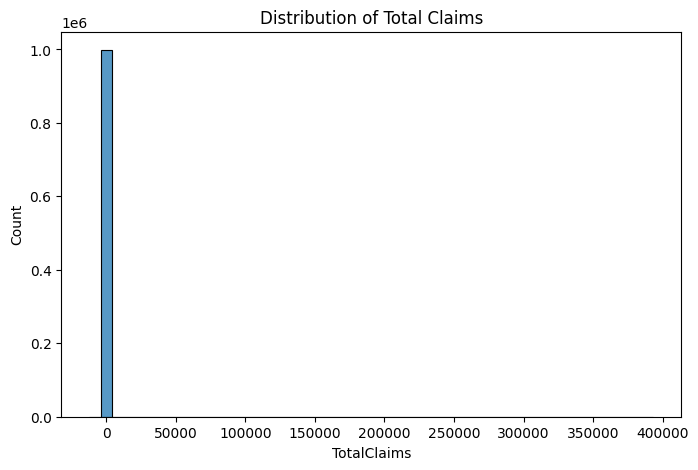

In [31]:
#Histogram — TotalClaims
plt.figure(figsize=(8,5))

sns.histplot(df['TotalClaims'], bins=50)

plt.title("Distribution of Total Claims")

plt.show()

# Univariate Analysis

The analysis of primary financial variables involved visualizing the distributions of `TotalClaims` and `TotalPremium` using histograms. These plots provide insight into the spread, concentration, and skewness of the insurance financial data.

### Observations

- Both `TotalClaims` and `TotalPremium` exhibit highly right-skewed distributions.
- Most policyholders generate relatively low claim amounts, while a small number of policies account for extremely high claims.
- The presence of skewness suggests that transformations or robust statistical methods may be necessary during modeling.

### Business Implication

The concentration of extreme claims among a limited number of policies highlights the importance of accurately identifying high-risk customers to improve profitability and pricing accuracy.

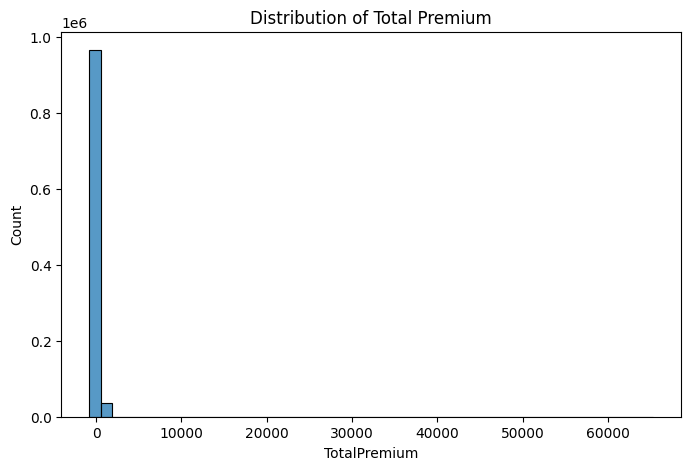

In [32]:
#Histogram — TotalPremium
plt.figure(figsize=(8,5))

sns.histplot(df['TotalPremium'], bins=50)

plt.title("Distribution of Total Premium")

plt.show()

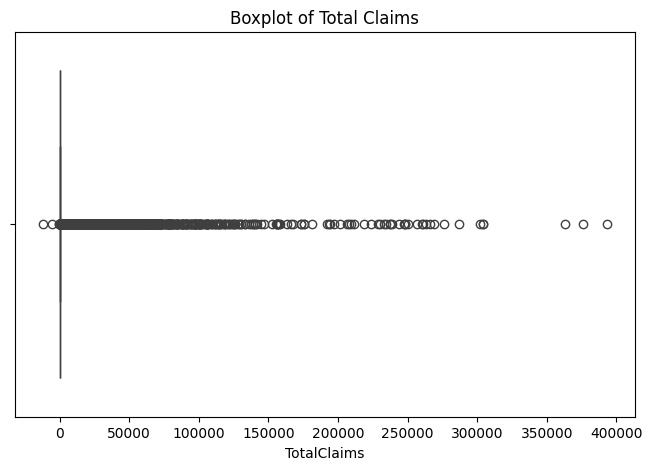

In [33]:
#Outliner detection
plt.figure(figsize=(8,5))

sns.boxplot(x=df['TotalClaims'])

plt.title("Boxplot of Total Claims")

plt.show()

# Outlier Detection

Boxplots were used to visualize the distribution of `TotalClaims` and other key numerical variables. This approach helps identify extreme observations that may disproportionately influence statistical analysis and predictive models.

### Observations

- Significant outliers are present in `TotalClaims`.
- A small number of policies exhibit exceptionally large claim values relative to the majority of observations.
- Similar outlier behavior may also exist within `CustomValueEstimate` and `SumInsured`.

### Business Implication

Extreme claim values may represent:
- High-risk policies
- Fraudulent claims
- Rare catastrophic events
- Data quality issues

These outliers should be carefully handled during modeling to avoid distorted predictions and unstable model performance.

---

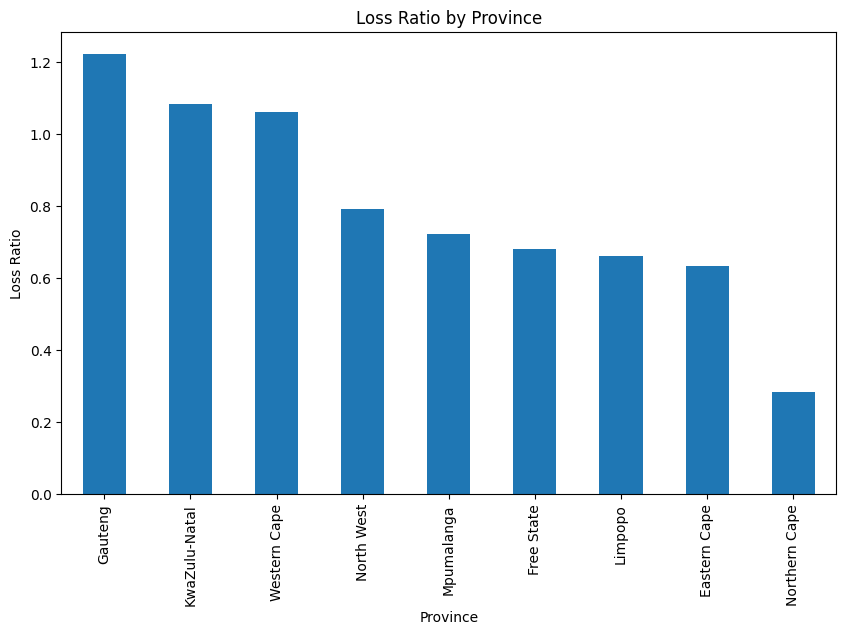

In [34]:
#Provision loss ratio
province = (
    df.groupby('Province')[['TotalClaims', 'TotalPremium']]
    .sum()
)

province['LossRatio'] = (
    province['TotalClaims'] /
    province['TotalPremium']
)

province = province.sort_values(
    by='LossRatio',
    ascending=False
)

province['LossRatio'].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Loss Ratio by Province")

plt.ylabel("Loss Ratio")

plt.show()

# Geographic Trends

Geographic analysis was performed by calculating and comparing the `LossRatio` across different provinces. The loss ratio measures the relationship between claims paid and premiums collected.

### Observations

- Certain provinces exhibit substantially higher loss ratios than others.
- Geographic regions with elevated loss ratios may indicate increased insurance risk exposure.
- Differences may be driven by factors such as traffic density, accident frequency, crime rates, or economic conditions.

### Business Implication

The findings suggest that province-specific pricing strategies may improve underwriting profitability. High-risk regions may require higher premiums or stricter underwriting policies.

---


In [35]:
#Gender analysis
gender = (
    df.groupby('Gender')[['TotalClaims', 'TotalPremium']]
    .sum()
)

gender['LossRatio'] = (
    gender['TotalClaims'] /
    gender['TotalPremium']
)

gender

,TotalClaims,TotalPremium,LossRatio
Gender,,,
Female,2.502461e+05,3.044806e+05,0.821879
Male,1.396704e+06,1.580143e+06,0.883910
Not specified,6.271410e+07,5.920275e+07,1.059311


# Gender Analysis

The analysis evaluated insurance performance metrics across gender categories by calculating and comparing the `LossRatio`.

### Observations

- Differences in loss ratios between genders appear relatively moderate.
- Some variation exists in claim behavior and premium contribution across demographic groups.

### Business Implication

While gender may contribute to risk variation, additional statistical testing is necessary to determine whether these differences are statistically significant enough to justify segmentation strategies.

---

In [36]:
#veichele type
vehicle = (
    df.groupby('VehicleType')['TotalClaims']
    .mean()
    .sort_values(ascending=False)
)

vehicle.head(10)

VehicleType
Heavy Commercial     101.401781
Medium Commercial     76.315030
Passenger Vehicle     63.594898
Light Commercial      15.512574
Bus                   12.024865
Name: TotalClaims, dtype: float64

# Vehicle Analysis

Vehicle-related trends were explored by grouping observations according to `VehicleType`, `make`, and `Model` to evaluate average claim amounts and claim frequency.

### Observations

- Certain vehicle makes and models are associated with substantially higher average claim amounts.
- Luxury vehicles and specialized commercial vehicles tend to exhibit elevated claim severity.
- Some vehicle categories consistently produce lower average claims and lower loss ratios.

### Business Implication

Vehicle characteristics are important predictors of insurance risk. These findings support the use of vehicle-specific premium adjustments and more granular pricing models.

---

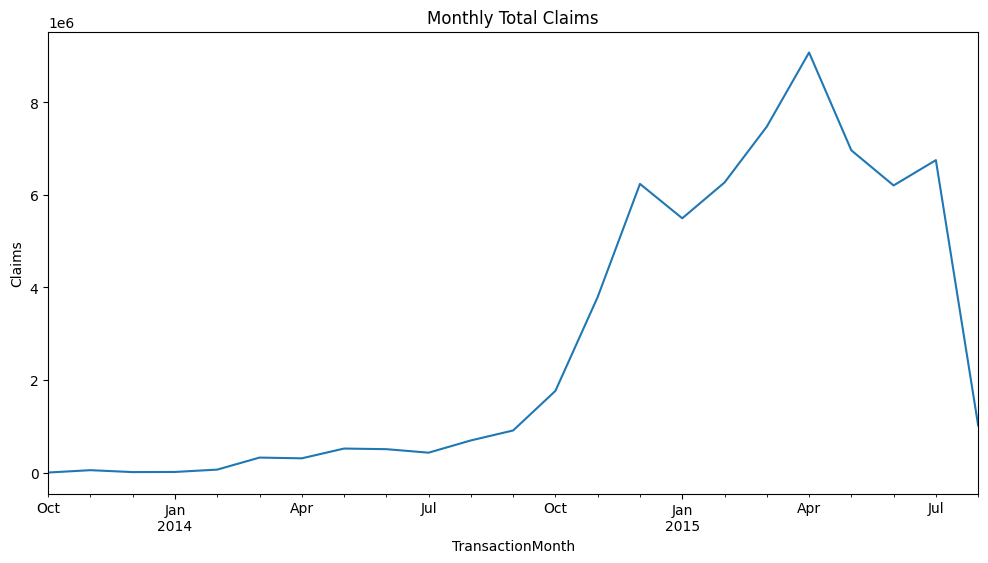

In [42]:
#temporal trend

df['TransactionMonth'] = pd.to_datetime(
    df['TransactionMonth'],
    errors='coerce'
)

monthly_claims = (
    df.groupby(df['TransactionMonth'].dt.to_period('M'))
    ['TotalClaims']
    .sum()
)

monthly_claims.plot(figsize=(12,6))

plt.title("Monthly Total Claims")

plt.ylabel("Claims")

plt.show()

# Temporal Trends

Temporal analysis was conducted by converting `TransactionMonth` into a datetime format and analyzing claim activity over time.

### Observations

- Claim volumes fluctuate across the 18-month observation period.
- Certain periods exhibit spikes in total claims, potentially indicating seasonal or economic influences.
- Variations in claim activity may reflect changing driving behavior, environmental conditions, or policy changes.

### Business Implication

Understanding temporal claim behavior helps insurers improve forecasting, reserve planning, and seasonal pricing strategies.

---

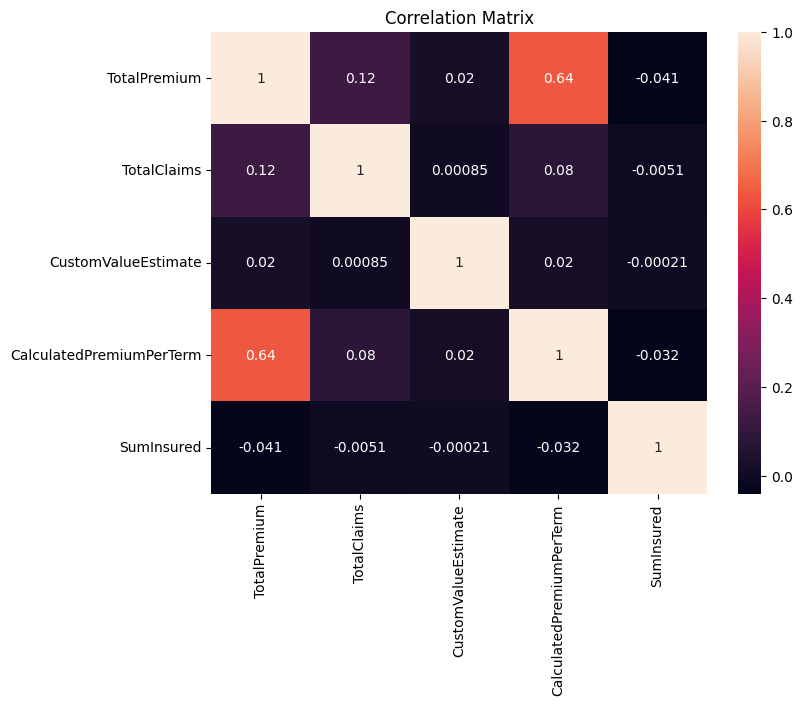

In [38]:
#correlation matrix
corr_cols = [
    'TotalPremium',
    'TotalClaims',
    'CustomValueEstimate',
    'CalculatedPremiumPerTerm',
    'SumInsured'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

# Correlation Analysis

Correlation analysis was performed using a heatmap and scatterplots for key financial variables such as `TotalPremium`, `TotalClaims`, `SumInsured`, and `CalculatedPremiumPerTerm`.

### Observations

- `TotalPremium` shows positive correlation with `SumInsured` and `CalculatedPremiumPerTerm`.
- Relationships between `TotalClaims` and other financial variables appear weaker and more variable.
- Scatterplots indicate substantial dispersion and the presence of outliers.

### Business Implication

The observed relationships confirm that premium calculations are partially aligned with insured value and policy characteristics. However, weaker claim correlations suggest that additional behavioral and geographic variables may be required for accurate risk prediction.

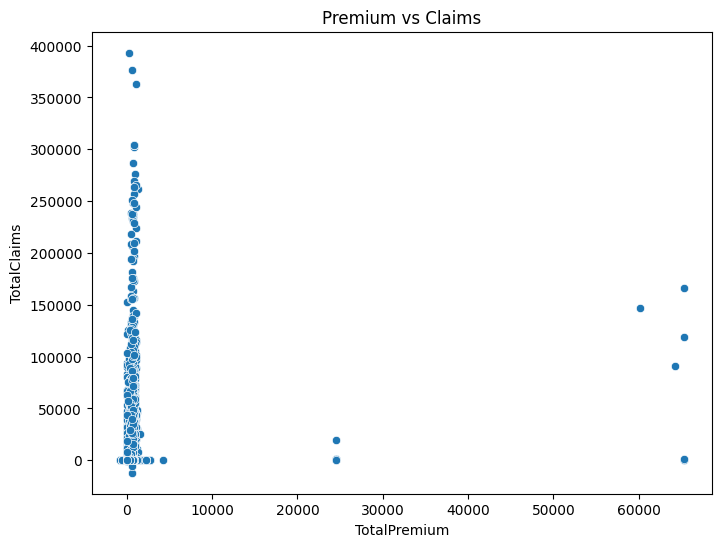

In [39]:
#Premius vs claim
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='TotalPremium',
    y='TotalClaims'
)

plt.title("Premium vs Claims")

plt.show()

In [40]:
#highest and lowest viechle
vehicle_claims = (
    df.groupby(['make', 'Model'])['TotalClaims']
    .mean()
    .sort_values(ascending=False)
)

vehicle_claims.head(10)

make                                 Model                      
TOYOTA                               L/CRUISER FJ 4.0 V6 CRUISER    5340.970273
HYUNDAI                              H-1 2.5 CRDI WAGON A/T         4118.181043
FIAT                                 DUCATO 2.3 JTD VETRATO         1014.681021
VOLKSWAGEN                           POLO VIVO 1.6 5Dr               827.558882
MERCEDES-BENZ                        C180 BE COUPE                   743.459027
                                     SPRINTER 312D F/C P/V           664.540138
SUZUKI                               ERTIGA 1.4 GA                   631.774519
TOYOTA                               YARIS T1 3Dr                    618.719846
AUDI                                 A4 1.8T S AVANT MULTITRONIC     480.282859
VOLKSWAGEN                           POLO 1.6 COMFORTLINE            431.842105
Name: TotalClaims, dtype: float64

In [41]:
vehicle_claims.tail(10)

make           Model                           
MERCEDES-BENZ  SPRINTER 315 CDI F/C P/V            0.000000
               SPRINTER 315 CDI F/C D/C            0.000000
               SPRINTER 315 CDI F/C C/C            0.000000
               SPRINTER 313 CDI HI ROOF F/C P/V    0.000000
               SPRINTER 313 CDI F/C D/C            0.000000
               SPRINTER 312D HIGH ROOF F/C P/V     0.000000
               SPRINTER 311 CDi F/C P/V            0.000000
               SPRINTER 308D F/C C/C               0.000000
VOLVO          S70 T5 A/T                          0.000000
MERCEDES-BENZ  C200K CLASSIC A/T                  -0.250832
Name: TotalClaims, dtype: float64